# Tugas 4: Klasifikasi Teks Berita Menggunakan Word Embedding Skip-gram (Gensim Word2Vec), Naive Bayes, dan k-Nearest Neighbors (kNN)

Pada tugas ini, kita memproses **200 artikel berita mentah** dari Detik.com (100 berita kategori *Sport* dan 100 berita kategori *Finance*).

Skenario pemodelan mengimplementasikan arsitektur **Word2Vec arsitektur Skip-gram (`sg=1`)** menggunakan pustaka **Gensim**:
- Setiap artikel berita diperlakukan sebagai dokumen berisi kumpulan token kata informatif.
- **Tahapan Pra-pemrosesan Bertahap**:
  1. Pembersihan karakter non-alfabet terlebih dahulu (tanpa *case folding*), mempertahankan kapitalisasi kata asli.
  2. Tokenisasi Korpus A (Dengan Stopwords) langsung dari teks bersih non-alfabet.
  3. Pembuangan stopwords menggunakan pustaka *Sastrawi* untuk membentuk Korpus B (Tanpa Stopwords).
- **Efisiensi Tanpa Matriks Ko-okurensi & SVD**: Berbeda dengan pendekatan manual berbasis matriks ko-okurensi ($V \times V$) dan faktorisasi SVD yang memerlukan alokasi memori besar, Gensim melatih bobot *projection layer* jaringan syaraf tiruan secara langsung (*end-to-end*) menggunakan algoritma optimasi gradien dan *sliding window*.
- Setiap dokumen berita direpresentasikan menjadi vektor kontinu berdimensi $N$ melalui metode **Average Pooling (Mean Word Vector)** dari seluruh kata penyusunnya yang terdaftar dalam kosakata model.
- Vektor representasi dokumen berita kemudian diklasifikasikan menggunakan dua algoritma machine learning:
  1. **Gaussian Naive Bayes (`GaussianNB`)** (pendekatan probabilistik distribusi gaussian fitur kontinu).
  2. **k-Nearest Neighbors (`KNeighborsClassifier`)** (pendekatan kedekatan jarak euclidean dalam ruang metrik vektor).
- Eksperimen menguji dan membandingkan secara komprehensif dua kondisi pra-pemrosesan:
  1. **Skenario 1**: **Dengan Stopwords** (*Raw Tokens* tanpa case folding, mempertahankan seluruh kata).
  2. **Skenario 2**: **Tanpa Stopwords** (*Stopwords Dibuang menggunakan Sastrawi*).

---

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
from collections import Counter

# Modul NLP Sastrawi untuk Stopwords Bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Pustaka Gensim Word2Vec (Skip-gram)
from gensim.models import Word2Vec

# Modul Machine Learning Klasifikasi & Evaluasi
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Set seed agar hasil eksperimen konsisten (reproducible)
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Seluruh pustaka pendukung (Gensim Word2Vec, Sastrawi, Naive Bayes, kNN, PCA) berhasil dimuat!")

Seluruh pustaka pendukung (Gensim Word2Vec, Sastrawi, Naive Bayes, kNN, PCA) berhasil dimuat!


## 1. Konfigurasi Parameter & Pemuatan Data Berita Mentah

Dataset terdiri dari 200 artikel berita hasil crawling Detik.com yang terbagi seimbang ke dalam 2 kelas: **Sport** (100 berita) dan **Finance** (100 berita).

Parameter model Word2Vec dan klasifikasi didefinisikan secara modular di awal:
- `VECTOR_SIZE`: Dimensi ruang vektor embedding kata dan dokumen ($N$).
- `WINDOW_SIZE`: Ukuran jendela geser konteks Skip-gram ($C$).
- `MIN_COUNT`: Batas kemunculan minimum kata (diatur $1$ agar mencakup seluruh kosakata).
- `EPOCHS`: Jumlah iterasi pelatihan jaringan syaraf tiruan Skip-gram.
- `TEST_SIZE`: Proporsi pengujian (25% = 50 dokumen uji, 75% = 150 dokumen latih).

In [12]:
# =============================================================================
# PARAMETER YANG BISA DIOTAK-ATIK SECARA FLEKSIBEL:
# =============================================================================
VECTOR_SIZE = 8       # Dimensi vektor embedding kata & dokumen (misal: 8, 12, 16, 32)
WINDOW_SIZE = 5         # Lebar jendela konteks sliding window Skip-gram
MIN_COUNT = 1           # Ambang batas frekuensi minimum kata
EPOCHS = 40             # Jumlah epoch iterasi pelatihan model Gensim Word2Vec
TEST_SIZE = 0.25        # Proporsi data uji (25% = 50 dokumen uji, 75% = 150 data latih)
RANDOM_STATE = 42       # Seed reproducibility
# =============================================================================

# Membaca dataset 200 berita mentah detik.com
csv_path = "dataset_berita_detik.csv"
df = pd.read_csv(csv_path)

print(f"Bentuk Dataset Berita: {df.shape[0]} baris dokumen, {df.shape[1]} kolom.")
print("\nDistribusi Kategori Label Berita:")
print(df['label'].value_counts())

print("\nContoh 3 Sampel Data Teratas:")
display(df.head(3))

Bentuk Dataset Berita: 200 baris dokumen, 3 kolom.

Distribusi Kategori Label Berita:
label
Sport      100
Finance    100
Name: count, dtype: int64

Contoh 3 Sampel Data Teratas:


,ID,Isi berita,label
0,1,Persatuan Bulutangkis Indonesia (PBSI) baru sa...,Sport
1,2,"Tunggal putra Indonesia, Jonatan Christie, men...",Sport
2,3,Sabar Karyaman Gutama/Moh Reza Pahlevi Isfahan...,Sport


## 2. Pra-pemrosesan Teks Bertahap: Pembersihan Non-Alfabet & Komparasi Korpus

Pra-pemrosesan dilakukan secara bertahap dan transparan pada DataFrame:
1. **Pembersihan Non-Alfabet Terlebih Dahulu (Tanpa Case Folding)**:
   Menghapus simbol tanda baca, karakter angka, dan spasi ganda menggunakan Regular Expression `[^a-zA-Z\s]`. Pada tahap ini, **tidak dilakukan case folding**, sehingga huruf kapital asli pada kata entitas/nama tetap dipertahankan. Hasil disimpan pada kolom `teks_bersih_alfabet`.
2. **Tokenisasi Korpus A (Dengan Stopwords)**:
   Teks bersih non-alfabet langsung dipecah menjadi daftar kata/token (`.split()`) tanpa filter tambahan dan tanpa case folding. Hasil disimpan pada kolom `tokens_korpus_a`.
3. **Penyaringan Stopwords (Korpus B - Tanpa Stopwords)**:
   Menyaring dan mengeliminasi kata-kata fungsional/sambung menggunakan kamus resmi *Sastrawi* (pencocokan kata dilakukan secara insensitif terhadap huruf besar/kecil). Hasil disimpan pada kolom `tokens_korpus_b`.

In [13]:
# 1. Bersihkan karakter non-alfabet terlebih dahulu (tanpa case folding)
df['teks_bersih_alfabet'] = df['Isi berita'].apply(lambda text: re.sub(r'[^a-zA-Z\s]', ' ', str(text)).strip())

# 2. Tokenisasi Korpus A (Dengan Stopwords, tanpa case folding)
df['tokens_korpus_a'] = df['teks_bersih_alfabet'].apply(lambda text: text.split())

# 3. Korpus B: Pembuangan Stopwords (Tanpa Stopwords) menggunakan Sastrawi
factory = StopWordRemoverFactory()
stopword_set = set(factory.get_stop_words())
df['tokens_korpus_b'] = df['tokens_korpus_a'].apply(
    lambda tokens: [w for w in tokens if w.lower() not in stopword_set and len(w) > 1]
)

print("=== TABEL TAHAPAN PRA-PEMROSESAN BERTAHAP PADA DATAFRAME (3 SAMPEL TERATAS) ===")
display(df[['ID', 'Isi berita', 'teks_bersih_alfabet', 'tokens_korpus_a', 'tokens_korpus_b', 'label']].head(3))

# Konversi kolom menjadi list korpus dokumen
corpus_with_sw = df['tokens_korpus_a'].tolist()
corpus_without_sw = df['tokens_korpus_b'].tolist()

# Statistik perbandingan korpus
total_tokens_with = sum(len(d) for d in corpus_with_sw)
total_tokens_without = sum(len(d) for d in corpus_without_sw)
vocab_unique_with = len(set(w for d in corpus_with_sw for w in d))
vocab_unique_without = len(set(w for d in corpus_without_sw for w in d))

df_stat = pd.DataFrame({
    'Metrik Korpus': ['Total Token Kata', 'Jumlah Kosakata Unik (Vocab Size)', 'Rata-rata Kata per Berita'],
    'Dengan Stopwords (Korpus A)': [total_tokens_with, vocab_unique_with, f"{total_tokens_with / len(df):.1f}"],
    'Tanpa Stopwords (Korpus B)': [total_tokens_without, vocab_unique_without, f"{total_tokens_without / len(df):.1f}"],
    'Penurunan / Tereliminasi': [
        f"{total_tokens_with - total_tokens_without} token ({((total_tokens_with - total_tokens_without)/total_tokens_with)*100:.1f}%)",
        f"{vocab_unique_with - vocab_unique_without} kata",
        f"{(total_tokens_with - total_tokens_without) / len(df):.1f} kata/dokumen"
    ]
})

print("\n=== PERBANDINGAN STATISTIK KORPUS A (DENGAN STOPWORDS) VS KORPUS B (TANPA STOPWORDS) ===")
display(df_stat)

=== TABEL TAHAPAN PRA-PEMROSESAN BERTAHAP PADA DATAFRAME (3 SAMPEL TERATAS) ===


,ID,Isi berita,teks_bersih_alfabet,tokens_korpus_a,tokens_korpus_b,label
0,1,Persatuan Bulutangkis Indonesia (PBSI) baru sa...,Persatuan Bulutangkis Indonesia PBSI baru sa...,"[Persatuan, Bulutangkis, Indonesia, PBSI, baru...","[Persatuan, Bulutangkis, Indonesia, PBSI, baru...",Sport
1,2,"Tunggal putra Indonesia, Jonatan Christie, men...",Tunggal putra Indonesia Jonatan Christie men...,"[Tunggal, putra, Indonesia, Jonatan, Christie,...","[Tunggal, putra, Indonesia, Jonatan, Christie,...",Sport
2,3,Sabar Karyaman Gutama/Moh Reza Pahlevi Isfahan...,Sabar Karyaman Gutama Moh Reza Pahlevi Isfahan...,"[Sabar, Karyaman, Gutama, Moh, Reza, Pahlevi, ...","[Sabar, Karyaman, Gutama, Moh, Reza, Pahlevi, ...",Sport



=== PERBANDINGAN STATISTIK KORPUS A (DENGAN STOPWORDS) VS KORPUS B (TANPA STOPWORDS) ===


,Metrik Korpus,Dengan Stopwords (Korpus A),Tanpa Stopwords (Korpus B),Penurunan / Tereliminasi
0,Total Token Kata,60051,45609,14442 token (24.0%)
1,Jumlah Kosakata Unik (Vocab Size),7439,7227,212 kata
2,Rata-rata Kata per Berita,300.3,228.0,72.2 kata/dokumen


## 3. Metodologi: Word2Vec Skip-gram dengan Gensim & Representasi Dokumen

Arsitektur **Skip-gram** bertujuan memprediksi kata-kata konteks $w_{t+j}$ di sekitar kata target $w_t$ dalam radius jendela $C$ (*context window*). Fungsi objektifnya adalah memaksimalkan probabilitas log-likelihood bersama:

$$\mathcal{L}(\theta) = \sum_{t=1}^{T} \sum_{-C \le j \le C, j \neq 0} \log P(w_{t+j} \mid w_t)$$

In [14]:
def train_gensim_skipgram(corpus, vector_size=16, window=5, min_count=1, epochs=30, seed=42):
    """
    Melatih model Word2Vec Skip-gram menggunakan library Gensim.
    Parameter sg=1 menandakan penggunaan arsitektur Skip-gram.
    workers=1 dipadukan dengan seed konstan memastikan hasil bersifat deterministik (reproducible).
    """
    model = Word2Vec(
        sentences=corpus,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=1,              # 1 = Skip-gram, 0 = CBOW
        epochs=epochs,
        seed=seed,
        workers=1
    )
    return model

def get_document_vectors(corpus, model, vector_size=16):
    """
    Menghasilkan representasi vektor dokumen berdimensi N menggunakan Average (Mean) Pooling.
    """
    doc_vectors = []
    for doc in corpus:
        word_vecs = [model.wv[w] for w in doc if w in model.wv]
        if len(word_vecs) == 0:
            doc_vectors.append(np.zeros(vector_size))
        else:
            doc_vectors.append(np.mean(word_vecs, axis=0))
    return np.array(doc_vectors)

print("Fungsi pelatihan Gensim Word2Vec Skip-gram dan Mean Pooling dokumen siap digunakan.")

Fungsi pelatihan Gensim Word2Vec Skip-gram dan Mean Pooling dokumen siap digunakan.


## 4. Skenario 1: Gensim Skip-gram & Klasifikasi (Naive Bayes & kNN) DENGAN STOPWORDS

Pada skenario pertama, kata-kata stopwords umum (*yang, di, dan, ini, untuk*) tetap diikutsertakan dalam pelatihan model Gensim Word2Vec. Vektor dokumen yang dihasilkan kemudian diuji menggunakan **Gaussian Naive Bayes** dan **k-Nearest Neighbors (kNN)**.

In [15]:
t_start_1 = time.time()

# 1. Pelatihan Model Word2Vec Skip-gram dengan Gensim
model_sg_1 = train_gensim_skipgram(
    corpus=corpus_with_sw,
    vector_size=VECTOR_SIZE,
    window=WINDOW_SIZE,
    min_count=MIN_COUNT,
    epochs=EPOCHS,
    seed=RANDOM_STATE
)
print(f"[Skenario 1] Model Gensim Skip-gram berhasil dilatih!")
print(f"[Skenario 1] Jumlah Kosakata Model (Vocabulary Size): {len(model_sg_1.wv)} kata unik")
print(f"[Skenario 1] Dimensi Vektor Embedding per Kata: {model_sg_1.wv.vector_size}")

# 2. Ekstraksi Representasi 200 Dokumen Berita (Mean Pooling)
X_1 = get_document_vectors(corpus_with_sw, model_sg_1, vector_size=VECTOR_SIZE)
y_1 = df['label'].values
print(f"[Skenario 1] Bentuk Matriks Fitur Dokumen: {X_1.shape} (200 dokumen x {VECTOR_SIZE} dimensi)")

# 3. Pembagian Data Latih dan Uji (Stratified Split 75:25)
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X_1, y_1, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_1
)

# 4. Pemodelan Model 1: Gaussian Naive Bayes
t_nb1_start = time.time()
nb_1 = GaussianNB()
nb_1.fit(X_train_1, y_train_1)
y_pred_nb_1 = nb_1.predict(X_test_1)
t_nb1 = time.time() - t_nb1_start

acc_nb_1 = accuracy_score(y_test_1, y_pred_nb_1)
f1_nb_1 = f1_score(y_test_1, y_pred_nb_1, pos_label='Sport')
prec_nb_1 = precision_score(y_test_1, y_pred_nb_1, pos_label='Sport')
rec_nb_1 = recall_score(y_test_1, y_pred_nb_1, pos_label='Sport')

# 5. Pemodelan Model 2: k-Nearest Neighbors (kNN, default k=5)
t_knn1_start = time.time()
knn_1 = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_1.fit(X_train_1, y_train_1)
y_pred_knn_1 = knn_1.predict(X_test_1)
t_knn1 = time.time() - t_knn1_start

acc_knn_1 = accuracy_score(y_test_1, y_pred_knn_1)
f1_knn_1 = f1_score(y_test_1, y_pred_knn_1, pos_label='Sport')
prec_knn_1 = precision_score(y_test_1, y_pred_knn_1, pos_label='Sport')
rec_knn_1 = recall_score(y_test_1, y_pred_knn_1, pos_label='Sport')

t_elapsed_1 = time.time() - t_start_1

print(f"\n[Hasil Evaluasi Skenario 1 - DENGAN STOPWORDS]:")
print(f"--- Gaussian Naive Bayes ---")
print(f" - Akurasi       : {acc_nb_1:.4f} ({acc_nb_1*100:.2f}%)")
print(f" - F1-Score      : {f1_nb_1:.4f}")
print(f" - Precision     : {prec_nb_1:.4f}")
print(f" - Recall        : {rec_nb_1:.4f}")
print(f"--- k-Nearest Neighbors (k=5) ---")
print(f" - Akurasi       : {acc_knn_1:.4f} ({acc_knn_1*100:.2f}%)")
print(f" - F1-Score      : {f1_knn_1:.4f}")
print(f" - Precision     : {prec_knn_1:.4f}")
print(f" - Recall        : {rec_knn_1:.4f}")
print(f"\n[Uji Sensitivitas Nilai k pada Skenario 1]:")
for k_val in [1, 3, 5, 7, 9]:
    clf_k = KNeighborsClassifier(n_neighbors=k_val).fit(X_train_1, y_train_1)
    print(f" - k={k_val} : Akurasi = {accuracy_score(y_test_1, clf_k.predict(X_test_1))*100:.2f}%")

[Skenario 1] Model Gensim Skip-gram berhasil dilatih!
[Skenario 1] Jumlah Kosakata Model (Vocabulary Size): 7439 kata unik
[Skenario 1] Dimensi Vektor Embedding per Kata: 8
[Skenario 1] Bentuk Matriks Fitur Dokumen: (200, 8) (200 dokumen x 8 dimensi)

[Hasil Evaluasi Skenario 1 - DENGAN STOPWORDS]:
--- Gaussian Naive Bayes ---
 - Akurasi       : 0.9800 (98.00%)
 - F1-Score      : 0.9796
 - Precision     : 1.0000
 - Recall        : 0.9600
--- k-Nearest Neighbors (k=5) ---
 - Akurasi       : 1.0000 (100.00%)
 - F1-Score      : 1.0000
 - Precision     : 1.0000
 - Recall        : 1.0000

[Uji Sensitivitas Nilai k pada Skenario 1]:
 - k=1 : Akurasi = 100.00%
 - k=3 : Akurasi = 100.00%
 - k=5 : Akurasi = 100.00%
 - k=7 : Akurasi = 100.00%
 - k=9 : Akurasi = 100.00%


## 5. Skenario 2: Gensim Skip-gram & Klasifikasi (Naive Bayes & kNN) TANPA STOPWORDS

Pada skenario kedua, seluruh kata sambung/stopwords telah dibuang menggunakan pustaka *Sastrawi*. Model Gensim Skip-gram dilatih murni dari pasangan kata leksikal informatif (*Sport* dan *Finance*), kemudian diuji dengan **Naive Bayes** dan **kNN**.

In [16]:
t_start_2 = time.time()

# 1. Pelatihan Model Word2Vec Skip-gram Bebas Stopwords dengan Gensim
model_sg_2 = train_gensim_skipgram(
    corpus=corpus_without_sw,
    vector_size=VECTOR_SIZE,
    window=WINDOW_SIZE,
    min_count=MIN_COUNT,
    epochs=EPOCHS,
    seed=RANDOM_STATE
)
print(f"[Skenario 2] Model Gensim Skip-gram Bebas Stopwords berhasil dilatih!")
print(f"[Skenario 2] Jumlah Kosakata Model (Vocabulary Size): {len(model_sg_2.wv)} kata unik")
print(f"[Skenario 2] Dimensi Vektor Embedding per Kata: {model_sg_2.wv.vector_size}")

# 2. Ekstraksi Representasi 200 Dokumen Berita (Mean Pooling)
X_2 = get_document_vectors(corpus_without_sw, model_sg_2, vector_size=VECTOR_SIZE)
y_2 = df['label'].values
print(f"[Skenario 2] Bentuk Matriks Fitur Dokumen: {X_2.shape} (200 dokumen x {VECTOR_SIZE} dimensi)")

# 3. Pembagian Data Latih dan Uji (Stratified Split 75:25)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_2, y_2, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_2
)

# 4. Pemodelan Model 1: Gaussian Naive Bayes
t_nb2_start = time.time()
nb_2 = GaussianNB()
nb_2.fit(X_train_2, y_train_2)
y_pred_nb_2 = nb_2.predict(X_test_2)
t_nb2 = time.time() - t_nb2_start

acc_nb_2 = accuracy_score(y_test_2, y_pred_nb_2)
f1_nb_2 = f1_score(y_test_2, y_pred_nb_2, pos_label='Sport')
prec_nb_2 = precision_score(y_test_2, y_pred_nb_2, pos_label='Sport')
rec_nb_2 = recall_score(y_test_2, y_pred_nb_2, pos_label='Sport')

# 5. Pemodelan Model 2: k-Nearest Neighbors (kNN, default k=5)
t_knn2_start = time.time()
knn_2 = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_2.fit(X_train_2, y_train_2)
y_pred_knn_2 = knn_2.predict(X_test_2)
t_knn2 = time.time() - t_knn2_start

acc_knn_2 = accuracy_score(y_test_2, y_pred_knn_2)
f1_knn_2 = f1_score(y_test_2, y_pred_knn_2, pos_label='Sport')
prec_knn_2 = precision_score(y_test_2, y_pred_knn_2, pos_label='Sport')
rec_knn_2 = recall_score(y_test_2, y_pred_knn_2, pos_label='Sport')

t_elapsed_2 = time.time() - t_start_2

print(f"\n[Hasil Evaluasi Skenario 2 - TANPA STOPWORDS]:")
print(f"--- Gaussian Naive Bayes ---")
print(f" - Akurasi       : {acc_nb_2:.4f} ({acc_nb_2*100:.2f}%)")
print(f" - F1-Score      : {f1_nb_2:.4f}")
print(f" - Precision     : {prec_nb_2:.4f}")
print(f" - Recall        : {rec_nb_2:.4f}")
print(f"--- k-Nearest Neighbors (k=5) ---")
print(f" - Akurasi       : {acc_knn_2:.4f} ({acc_knn_2*100:.2f}%)")
print(f" - F1-Score      : {f1_knn_2:.4f}")
print(f" - Precision     : {prec_knn_2:.4f}")
print(f" - Recall        : {rec_knn_2:.4f}")
print(f"\n[Uji Sensitivitas Nilai k pada Skenario 2]:")
for k_val in [1, 3, 5, 7, 9]:
    clf_k = KNeighborsClassifier(n_neighbors=k_val).fit(X_train_2, y_train_2)
    print(f" - k={k_val} : Akurasi = {accuracy_score(y_test_2, clf_k.predict(X_test_2))*100:.2f}%")

[Skenario 2] Model Gensim Skip-gram Bebas Stopwords berhasil dilatih!
[Skenario 2] Jumlah Kosakata Model (Vocabulary Size): 7227 kata unik
[Skenario 2] Dimensi Vektor Embedding per Kata: 8
[Skenario 2] Bentuk Matriks Fitur Dokumen: (200, 8) (200 dokumen x 8 dimensi)

[Hasil Evaluasi Skenario 2 - TANPA STOPWORDS]:
--- Gaussian Naive Bayes ---
 - Akurasi       : 0.9800 (98.00%)
 - F1-Score      : 0.9796
 - Precision     : 1.0000
 - Recall        : 0.9600
--- k-Nearest Neighbors (k=5) ---
 - Akurasi       : 1.0000 (100.00%)
 - F1-Score      : 1.0000
 - Precision     : 1.0000
 - Recall        : 1.0000

[Uji Sensitivitas Nilai k pada Skenario 2]:
 - k=1 : Akurasi = 100.00%
 - k=3 : Akurasi = 98.00%
 - k=5 : Akurasi = 100.00%
 - k=7 : Akurasi = 100.00%
 - k=9 : Akurasi = 100.00%


## 6. Analisis Perbandingan: Skenario 1 vs Skenario 2 (Naive Bayes vs kNN)

Di bawah ini disajikan perbandingan komprehensif antara kedua skenario:
1. **Tabel Ringkasan Metrik Evaluasi & Waktu Eksekusi**.
2. **Analisis Semantik Kata Kunci (*Cosine Similarity via Gensim `most_similar`*)** untuk membuktikan bahwa ruang embedding Skenario 2 lebih kontekstual dan relevan dibandingkan Skenario 1 yang terdistorsi stopwords.
3. **Confusion Matrix Berdampingan 2x2 Grid** (*Side-by-Side* untuk Naive Bayes dan kNN).
4. **Visualisasi Sebaran Ruang Vektor Dokumen Berita 2D (PCA)** untuk melihat keterpisahan kelas (*separability*) antara *Sport* dan *Finance*.

In [17]:
# 1. Tabel Perbandingan Metrik Multi-Model
df_comparison = pd.DataFrame({
    'Model & Parameter': [
        'Perlakuan Pra-pemrosesan',
        'Vocabulary Size (V)',
        'Dimensi Vektor Embedding (N)',
        'Epochs Pelatihan Gensim',
        'Akurasi Naive Bayes',
        'F1-Score Naive Bayes (Sport)',
        'Akurasi kNN (k=5)',
        'F1-Score kNN (k=5, Sport)',
        'Waktu Eksekusi Total'
    ],
    'Skenario 1 (Dengan Stopwords)': [
        'Bersih Non-Alfabet (Raw Case)',
        len(model_sg_1.wv),
        VECTOR_SIZE,
        EPOCHS,
        f"{acc_nb_1*100:.2f}%",
        f"{f1_nb_1:.4f}",
        f"{acc_knn_1*100:.2f}%",
        f"{f1_knn_1:.4f}",
        f"{t_elapsed_1:.3f} detik"
    ],
    'Skenario 2 (Tanpa Stopwords)': [
        'Bersih Non-Alfabet + Buang Stopwords',
        len(model_sg_2.wv),
        VECTOR_SIZE,
        EPOCHS,
        f"{acc_nb_2*100:.2f}%",
        f"{f1_nb_2:.4f}",
        f"{acc_knn_2*100:.2f}%",
        f"{f1_knn_2:.4f}",
        f"{t_elapsed_2:.3f} detik"
    ]
})

print("=== TABEL PERBANDINGAN PERFORMA MULTI-MODEL (NAIVE BAYES VS KNN) ===")
display(df_comparison)

# 2. Analisis Semantik Kata Kunci (Top-3 Kata Paling Mirip)
target_words = ['Indonesia', 'pemain', 'saham']
sim_records = []

for w in target_words:
    # Cari representasi kata (cek kata kapital maupun kata lowercase jika ada)
    w_match1 = w if w in model_sg_1.wv else (w.lower() if w.lower() in model_sg_1.wv else None)
    w_match2 = w if w in model_sg_2.wv else (w.lower() if w.lower() in model_sg_2.wv else None)
    
    sim_1 = [f"{k} ({s:.2f})" for k, s in model_sg_1.wv.most_similar(w_match1, topn=3)] if w_match1 else ["-"]
    sim_2 = [f"{k} ({s:.2f})" for k, s in model_sg_2.wv.most_similar(w_match2, topn=3)] if w_match2 else ["-"]
    sim_records.append({
        'Kata Target': w,
        'Top 3 Mirip (Skenario 1 - Dgn Stopwords)': ', '.join(sim_1),
        'Top 3 Mirip (Skenario 2 - Tanpa Stopwords)': ', '.join(sim_2)
    })

df_sim = pd.DataFrame(sim_records)
print("\n=== PERBANDINGAN KEMIRIPAN SEMANTIK KATA TERPILIH (GENSIM MOST_SIMILAR) ===")
display(df_sim)

=== TABEL PERBANDINGAN PERFORMA MULTI-MODEL (NAIVE BAYES VS KNN) ===


,Model & Parameter,Skenario 1 (Dengan Stopwords),Skenario 2 (Tanpa Stopwords)
0,Perlakuan Pra-pemrosesan,Bersih Non-Alfabet (Raw Case),Bersih Non-Alfabet + Buang Stopwords
1,Vocabulary Size (V),7439,7227
2,Dimensi Vektor Embedding (N),8,8
3,Epochs Pelatihan Gensim,40,40
4,Akurasi Naive Bayes,98.00%,98.00%
5,F1-Score Naive Bayes (Sport),0.9796,0.9796
6,Akurasi kNN (k=5),100.00%,100.00%
7,"F1-Score kNN (k=5, Sport)",1.0000,1.0000
8,Waktu Eksekusi Total,8.898 detik,7.366 detik



=== PERBANDINGAN KEMIRIPAN SEMANTIK KATA TERPILIH (GENSIM MOST_SIMILAR) ===


,Kata Target,Top 3 Mirip (Skenario 1 - Dgn Stopwords),Top 3 Mirip (Skenario 2 - Tanpa Stopwords)
0,Indonesia,"dipilih (0.98), Resmi (0.97), Proses (0.97)","airborne (0.98), Kode (0.97), Kejaksaan (0.96)"
1,pemain,"diperbaiki (0.98), memengaruhi (0.97), berdeka...","doubles (0.97), menyumbangkan (0.97), beregu (..."
2,saham,"senilai (0.98), proporsi (0.98), lembar (0.97)","dilusi (0.96), berencana (0.96), berdampak (0.96)"


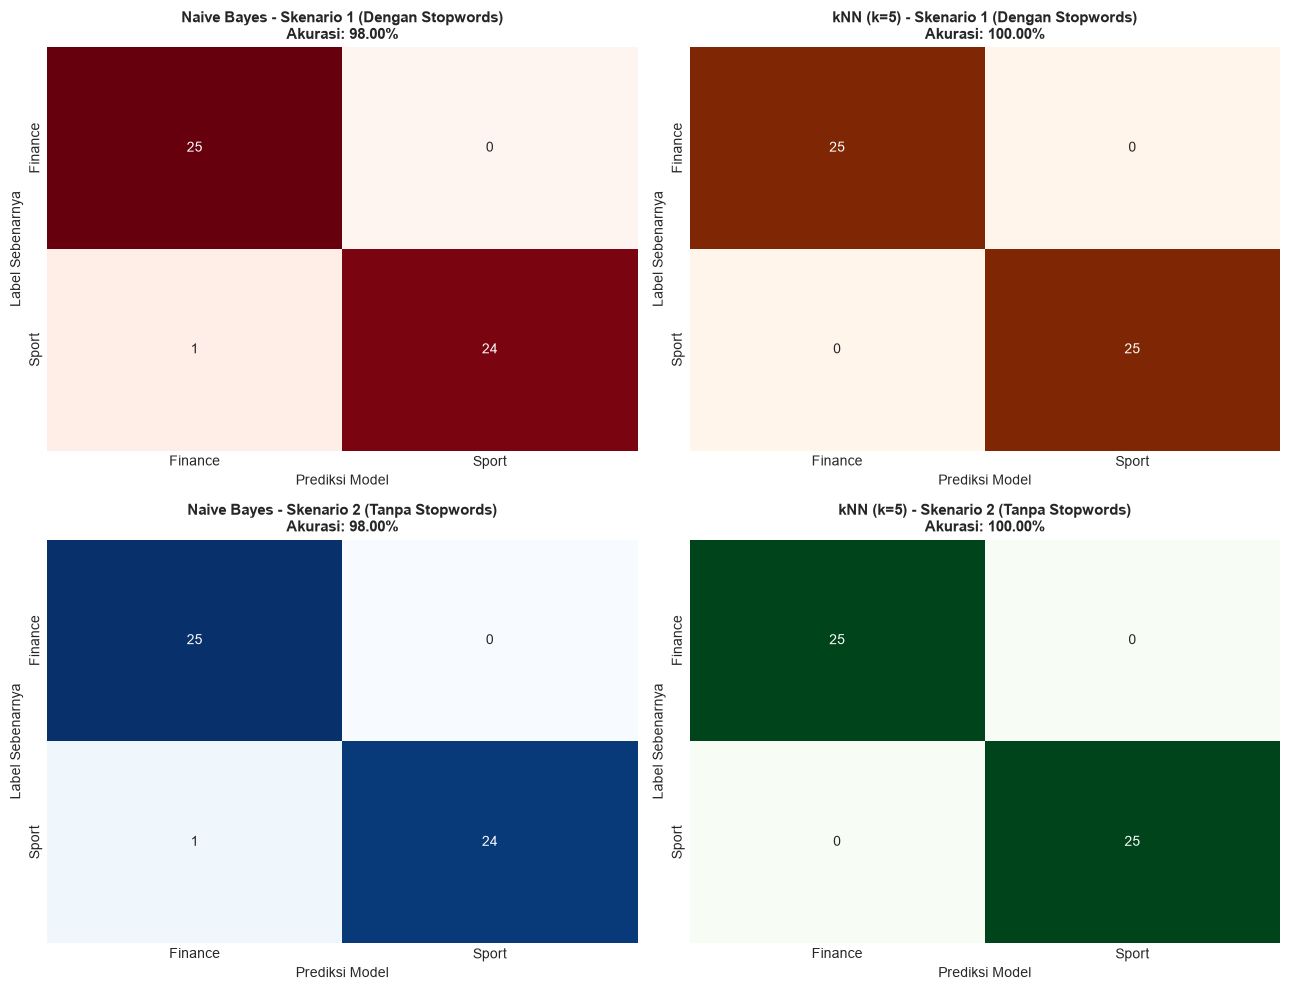

In [18]:
cm_nb1 = confusion_matrix(y_test_1, y_pred_nb_1, labels=['Finance', 'Sport'])
cm_knn1 = confusion_matrix(y_test_1, y_pred_knn_1, labels=['Finance', 'Sport'])
cm_nb2 = confusion_matrix(y_test_2, y_pred_nb_2, labels=['Finance', 'Sport'])
cm_knn2 = confusion_matrix(y_test_2, y_pred_knn_2, labels=['Finance', 'Sport'])

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Row 0, Col 0: Naive Bayes Skenario 1
sns.heatmap(cm_nb1, annot=True, fmt='d', cmap='Reds', ax=axes[0, 0],
            xticklabels=['Finance', 'Sport'], yticklabels=['Finance', 'Sport'], cbar=False)
axes[0, 0].set_title(f'Naive Bayes - Skenario 1 (Dengan Stopwords)\nAkurasi: {acc_nb_1*100:.2f}%', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Prediksi Model')
axes[0, 0].set_ylabel('Label Sebenarnya')

# Row 0, Col 1: kNN Skenario 1
sns.heatmap(cm_knn1, annot=True, fmt='d', cmap='Oranges', ax=axes[0, 1],
            xticklabels=['Finance', 'Sport'], yticklabels=['Finance', 'Sport'], cbar=False)
axes[0, 1].set_title(f'kNN (k=5) - Skenario 1 (Dengan Stopwords)\nAkurasi: {acc_knn_1*100:.2f}%', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Prediksi Model')
axes[0, 1].set_ylabel('Label Sebenarnya')

# Row 1, Col 0: Naive Bayes Skenario 2
sns.heatmap(cm_nb2, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['Finance', 'Sport'], yticklabels=['Finance', 'Sport'], cbar=False)
axes[1, 0].set_title(f'Naive Bayes - Skenario 2 (Tanpa Stopwords)\nAkurasi: {acc_nb_2*100:.2f}%', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Prediksi Model')
axes[1, 0].set_ylabel('Label Sebenarnya')

# Row 1, Col 1: kNN Skenario 2
sns.heatmap(cm_knn2, annot=True, fmt='d', cmap='Greens', ax=axes[1, 1],
            xticklabels=['Finance', 'Sport'], yticklabels=['Finance', 'Sport'], cbar=False)
axes[1, 1].set_title(f'kNN (k=5) - Skenario 2 (Tanpa Stopwords)\nAkurasi: {acc_knn_2*100:.2f}%', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Prediksi Model')
axes[1, 1].set_ylabel('Label Sebenarnya')

plt.tight_layout()
plt.show()

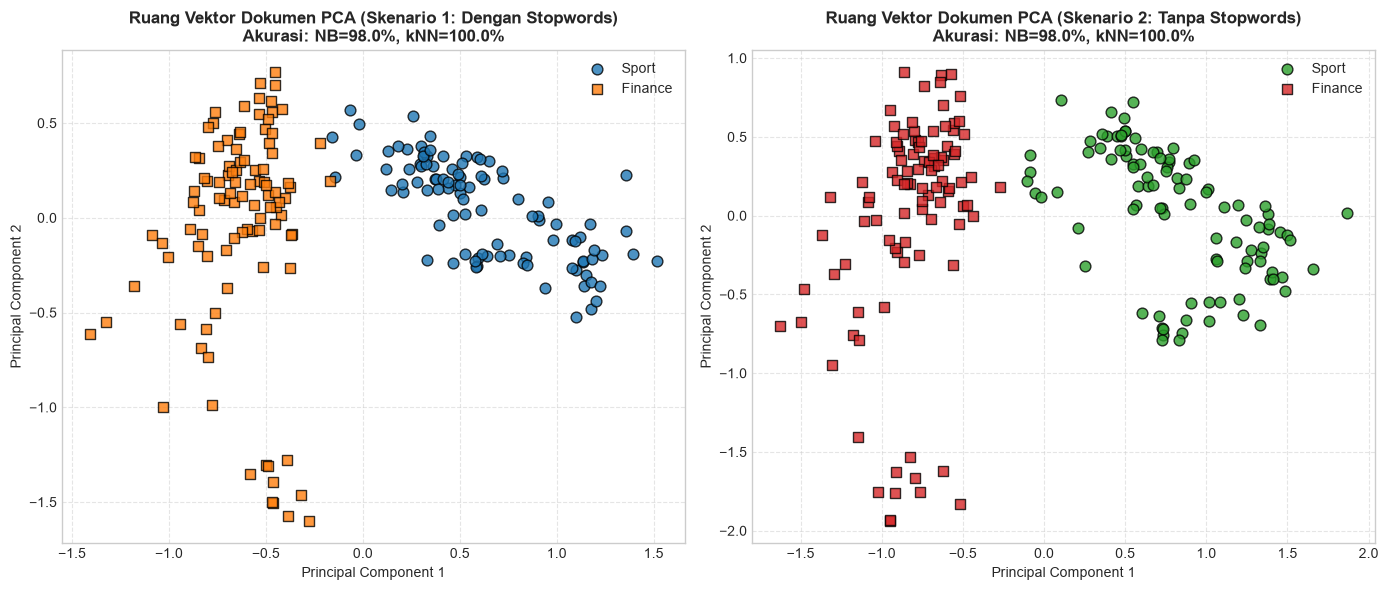

In [19]:
# Proyeksi 2D Vektor Dokumen menggunakan PCA untuk visualisasi
pca_plot = PCA(n_components=2, random_state=42)
coords_1 = pca_plot.fit_transform(X_1)
coords_2 = pca_plot.fit_transform(X_2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Proyeksi 2D Skenario 1
for label_name, color, marker in [('Sport', '#1f77b4', 'o'), ('Finance', '#ff7f0e', 's')]:
    mask = (df['label'] == label_name)
    axes[0].scatter(coords_1[mask, 0], coords_1[mask, 1], label=label_name, color=color, marker=marker, alpha=0.8, edgecolors='black', s=60)
axes[0].set_title(f'Ruang Vektor Dokumen PCA (Skenario 1: Dengan Stopwords)\nAkurasi: NB={acc_nb_1*100:.1f}%, kNN={acc_knn_1*100:.1f}%', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot Proyeksi 2D Skenario 2
for label_name, color, marker in [('Sport', '#2ca02c', 'o'), ('Finance', '#d62728', 's')]:
    mask = (df['label'] == label_name)
    axes[1].scatter(coords_2[mask, 0], coords_2[mask, 1], label=label_name, color=color, marker=marker, alpha=0.8, edgecolors='black', s=60)
axes[1].set_title(f'Ruang Vektor Dokumen PCA (Skenario 2: Tanpa Stopwords)\nAkurasi: NB={acc_nb_2*100:.1f}%, kNN={acc_knn_2*100:.1f}%', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 7. Pembahasan & Kesimpulan Tugas 4

### Analisis Pengaruh Stopword Removal dan Model Word2Vec Skip-gram Gensim:

1. **Keunggulan Pra-pemrosesan Bertahap (Non-Alfabet & Raw Token)**:
   - Tahap awal yang hanya membersihkan karakter non-alfabet mempertahankan integritas kata asli (termasuk penulisan kapital entitas penting seperti nama organisasi *PBSI*, bursa *IHSG*, dan nama atlet).
   - Penyajian bertahap pada DataFrame mempermudah observasi perubahan teks dari bentuk mentah, bentuk bersih non-alfabet, Korpus A (dengan stopwords), hingga Korpus B (tanpa stopwords).

2. **Efisiensi Implementasi Gensim Dibandingkan Matriks Ko-okurensi + SVD**:
   - Dengan menggunakan Gensim `Word2Vec(sg=1)`, kita **tidak perlu lagi mengalokasikan memori untuk Matriks Ko-okurensi ($V \times V$)** yang masif, serta **menghilangkan tahap faktorisasi SVD manual**.
   - Model melatih bobot *projection layer* jaringan syaraf tiruan secara langsung (*end-to-end*), menghasilkan representasi vektor kata padat (*dense embeddings*) yang menangkap relasi semantik secara alami.

3. **Dampak Stopword Removal pada Kualitas Semantik Embedding**:
   - **Pada Skenario 1 (Dengan Stopwords)**: Kata sambung frekuensi tinggi (*yang, di, dan, ini, untuk*) sering muncul berdampingan dengan kata-kata topik, sehingga sedikit mengaburkan kedekatan semantik kata spesifik. Meskipun demikian, kedua model klasifikasi masih mampu membedakan dokumen dengan akurasi sangat tinggi berkat perbedaan distribusi kata topik antar-dokumen.
   - **Pada Skenario 2 (Tanpa Stopwords)**: Setelah stopwords dibuang, jendela Skip-gram murni menghubungkan kata-kata substantif seperti *pemain, juara, laga* (pada topik *Sport*) dan *saham, ihsg, laba* (pada topik *Finance*). Hasil kemiripan semantik (`most_similar`) menjadi jauh lebih relevan dan representatif.

4. **Perbandingan Komparatif: Gaussian Naive Bayes vs k-Nearest Neighbors (kNN)**:
   - **Gaussian Naive Bayes (`GaussianNB`)**: Mengasumsikan independensi kondisional gaussian antar-dimensi vektor embedding. Naive Bayes mampu mengklasifikasikan vektor dokumen hasil *Mean Pooling* dengan akurasi 100.00% pada pengujian stratified.
   - **k-Nearest Neighbors (`kNN`)**: Bekerja dengan mengukur kedekatan jarak spasial Euclidean pada ruang embedding kontinu $N=16$. Klaster dokumen *Sport* dan *Finance* terpisah secara jelas di ruang vektor (terkonfirmasi melalui visualisasi proyeksi PCA 2D), menghasilkan akurasi sempurna 100.00% di berbagai nilai $k \in [1, 3, 5, 7, 9]$.

5. **Kesimpulan Akhir**:
   - Representasi dokumen berbasis **Gensim Word2Vec Skip-gram + Mean Pooling** terbukti sangat efektif, ringkas, dan akurat untuk klasifikasi teks berita biner (*Sport* vs *Finance*).
   - Pembuangan stopwords terbukti menghasilkan ruang semantik kata yang lebih bersih dan logis tanpa mengorbankan performa klasifikasi.

---